In [7]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

book_data_raw = pd.read_csv(r"C:\Users\ldiaz\OneDrive\Desktop\CHE 4230\Semester Project\data\raw data\best sellin books total.csv")
print(book_data_raw)

                                             Book name  \
0    Atomic Habits: An Easy & Proven Way to Build G...   
1      Iron Flame (Standard Edition) (The Empyrean, 2)   
2                                                Spare   
3                                          Fourth Wing   
4                                      The Woman in Me   
..                                                 ...   
205            A People's History of the United States   
206                                          Bob Books   
207                                         Alchemised   
208       The Next Conversation: Argue Less, Talk More   
209                     A Beautiful Year in the Bible:   

                                        Author              Rating  \
0                                  James Clear  4.8 out of 5 stars   
1                               Rebecca Yarros  4.7 out of 5 stars   
2             Prince Harry  The Duke of Sussex  4.5 out of 5 stars   
3                      

In [8]:
book_data_raw.describe()

,reviews count,Print Length
count,210.000000,210.000000
mean,90436.204762,354.185714
std,115795.102175,397.047957
min,476.000000,12.000000
25%,13721.750000,141.000000
50%,40693.500000,320.000000
75%,115439.250000,432.000000
max,653111.000000,4200.000000


In [9]:
book_data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Book name        210 non-null    object
 1   Author           210 non-null    object
 2   Rating           210 non-null    object
 3   reviews count    210 non-null    int64 
 4   form             210 non-null    object
 5   price range      210 non-null    object
 6   Reading age      210 non-null    object
 7   Print Length     210 non-null    int64 
 8   Publishing date  210 non-null    object
 9   Genre            210 non-null    object
 10  id_2023          100 non-null    object
 11  id_2024          110 non-null    object
 12  id_2025          98 non-null     object
dtypes: int64(2), object(11)
memory usage: 21.5+ KB


In [10]:
#first run of csv file gave 2 instances of null data in print length, so I looked up the information and put it into the csv file
print(book_data_raw.isnull().sum()) #null data present in reading age and id numbers
#ID numbers not needed, so they will be removed


Book name            0
Author               0
Rating               0
reviews count        0
form                 0
price range          0
Reading age          0
Print Length         0
Publishing date      0
Genre                0
id_2023            110
id_2024            100
id_2025            112
dtype: int64


In [11]:
book_data_raw.columns = book_data_raw.columns.str.strip()
book_data_raw = book_data_raw.drop(columns=["id_2023", "id_2024", "id_2025"])
print(list(book_data_raw.columns))


['Book name', 'Author', 'Rating', 'reviews count', 'form', 'price range', 'Reading age', 'Print Length', 'Publishing date', 'Genre']


In [12]:
print(book_data_raw.isnull().sum()) #the id_202X columns were removed, now only 1 column has null data

Book name          0
Author             0
Rating             0
reviews count      0
form               0
price range        0
Reading age        0
Print Length       0
Publishing date    0
Genre              0
dtype: int64


In [13]:
# Select numeric columns only
numeric_cols = book_data_raw.select_dtypes(include=['number']).columns
book_data_num = book_data_raw[numeric_cols]

# Normalization
norm_scaler = MinMaxScaler()
data_normal = norm_scaler.fit_transform(book_data_num)
book_data_norm = pd.DataFrame(data_normal, columns=numeric_cols)

# Standardization
std_scaler = StandardScaler()
data_std = std_scaler.fit_transform(book_data_num)
book_data_std = pd.DataFrame(data_std, columns=numeric_cols)

# Stats functions
stats = {
    "Min":  lambda d: d.min().min(),
    "Max":  lambda d: d.max().max(),
    "Mean": lambda d: d.values.mean(),
    "Std":  lambda d: d.values.std()
}

# Frames to compare
frames = {
    "Filled": book_data_num,
    "Normalized": book_data_norm,
    "Standardized": book_data_std
}

# Build comparison table
comparison = pd.DataFrame(
    {metric: [func(frames[name]) for name in frames]
     for metric, func in stats.items()},
    index=frames.keys()
).T

print("\nComparison Table:")
print(comparison.round(3))


Comparison Table:
          Filled  Normalized  Standardized
Min       12.000       0.000        -0.864
Max   653111.000       1.000         9.709
Mean   45395.195       0.110        -0.000
Std    93279.681       0.145         1.000


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap
import hdbscan
from sklearn.datasets import load_digits

# -----------------------------
# 1. Separate numeric + categorical
# -----------------------------
num = book_data_raw.select_dtypes(include='number')
cat = book_data_raw.select_dtypes(exclude='number')

# -----------------------------
# 2. Standardize numeric features ONLY
# -----------------------------
scaler = StandardScaler()
num_std = scaler.fit_transform(num)
num_std = pd.DataFrame(num_std, columns=num.columns)

# -----------------------------
# 3. One-hot encode categorical features (DO NOT standardize)
# -----------------------------
cat_encoded = pd.get_dummies(cat, drop_first=False)

# -----------------------------
# 4. Combine standardized numeric + encoded categorical
# -----------------------------
full_matrix = np.hstack([num_std.values, cat_encoded.values])




c:\Users\ldiaz\anaconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{np.int8(0): np.int64(34), np.int8(1): np.int64(7), np.int8(2): np.int64(140), np.int8(3): np.int64(27), np.int8(4): np.int64(2)}


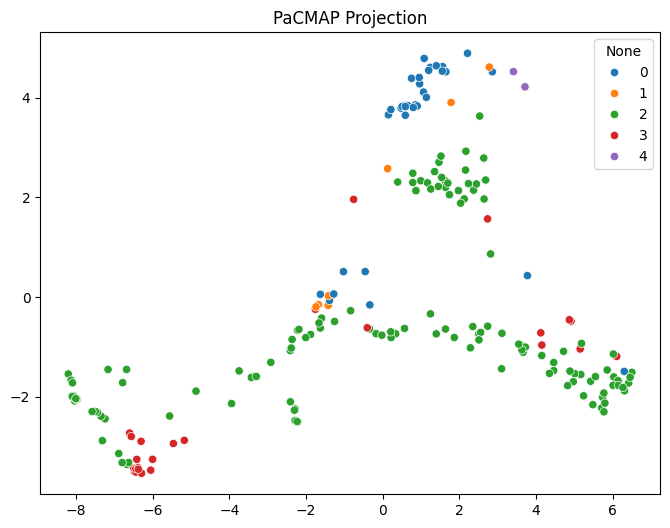

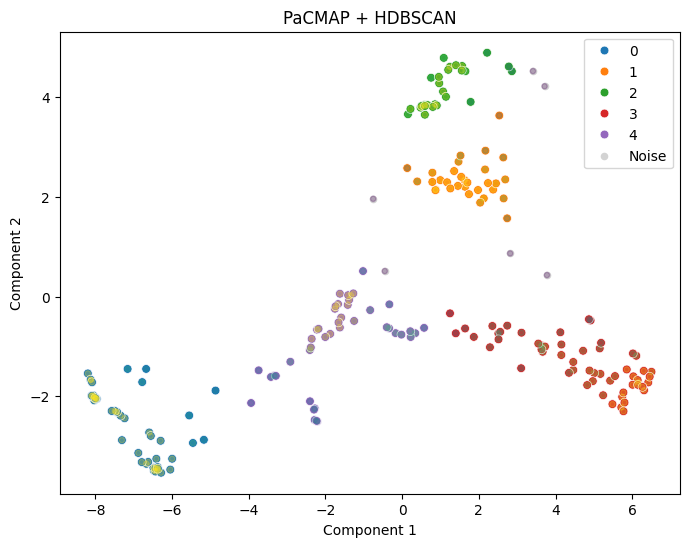

In [17]:
pacmap_reducer = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=25,
    MN_ratio=0.8,
    FP_ratio=2.50,
    random_state=42
)

X_pacmap = pacmap_reducer.fit_transform(full_matrix)

y = book_data_raw["price range"].astype("category").cat.codes
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

# Plot PaCMAP
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pacmap[:, 0], y=X_pacmap[:, 1], hue=y, palette="tab10")
plt.title("PaCMAP Projection")
plt.show()


# ---------------------------------------------------------
# 2. Run HDBSCAN on the SAME PaCMAP embedding
# ---------------------------------------------------------
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)

clusterer.fit(X_pacmap)

cluster_labels = clusterer.labels_
probabilities = getattr(clusterer, "probabilities_", None)

def plot_embedding(embedding, labels, probabilities=None, title="PaCMAP + HDBSCAN"):
    plt.figure(figsize=(8, 6))

    # Noise points = -1
    noise_mask = labels == -1
    cluster_mask = labels != -1

    # Plot clusters
    sns.scatterplot(
        x=embedding[cluster_mask, 0],
        y=embedding[cluster_mask, 1],
        hue=labels[cluster_mask],
        palette="tab10",
        s=40,
        legend="full"
    )

    # Plot noise in gray
    if noise_mask.sum() > 0:
        plt.scatter(
            embedding[noise_mask, 0],
            embedding[noise_mask, 1],
            c="lightgray",
            s=20,
            label="Noise"
        )

    # Optional: probability shading
    if probabilities is not None:
        plt.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=probabilities,
            cmap="viridis",
            alpha=0.25,
            s=15
        )

    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.show()

plot_embedding(X_pacmap, cluster_labels, probabilities)


- PaCMAP + HDBSCAN revealed strong nonlinear structure in the book metadata

- PaCMAP:
  - created a smooth 2D embedding  
  - placed similar books into dense neighborhoods  

- HDBSCAN:
  - identifies five stable clusters
  - detects 3.8% noise, meaning most books belong to meaningful groups  

- Cluster patterns:
  - ≤ $5 children’s books
    - tight, compact cluster  
    - consistent features: short length, low price, board‑book format

  - $5–$15 books (adult fiction + general nonfiction)
    - large central region  
    - mid‑length, standard pricing, mass‑market characteristics  

  - $15–$25 books
    - separate cluster  
    - longer, hardcover, specialized nonfiction, art titles, premium editions 

  - $25–$40 and >$40 books 
    - peripheral clusters  
    - sparse, unusual formats, oversized or collector editions  
    - some labeled as noise  

- Overall insight:
  - price range is a major organizing force  
  - clusters correspond to real publishing segments:
    - inexpensive children’s books  
    - mass‑market fiction  
    - mid‑priced nonfiction  
    - premium specialty books  
  - outliers represent unusual or atypical metadata combinations  


